# Multi-Layer Energy Balance Model (EBM)
### Atmosphere · Upper Ocean (0–200 m) · Lower Ocean (>200 m)

This extends the zero-dimensional EBM to **three coupled layers**, each with its own
heat capacity, so the fast atmospheric response and the slow deep-ocean heat uptake are
represented explicitly:

$$C_a\frac{dT_a}{dt} = S\bigl(1-\alpha(t)\bigr) - (a + bT_a) + F(t) - \gamma_{au}(T_a - T_u)$$
$$C_u\frac{dT_u}{dt} = \gamma_{au}(T_a - T_u) - \gamma_{ul}(T_u - T_l)$$
$$C_l\frac{dT_l}{dt} = \gamma_{ul}(T_u - T_l)$$

| Symbol | Meaning | Units |
|--------|---------|-------|
| $T_a,\,T_u,\,T_l$ | Atmosphere / upper-ocean / lower-ocean temperature | K |
| $C_a$ | Atmospheric-column heat capacity | W·yr/m²/°C |
| $C_u$ | Upper-ocean (0–200 m) heat capacity | W·yr/m²/°C |
| $C_l$ | Lower-ocean (>200 m) heat capacity | W·yr/m²/°C |
| $\gamma_{au}$ | Atmosphere ↔ upper-ocean heat exchange | W/m²/°C |
| $\gamma_{ul}$ | Upper ↔ lower-ocean heat exchange (deep uptake) | W/m²/°C |
| $S,\ \alpha(t),\ a+bT,\ F(t)$ | Insolation, albedo, OLR, CO₂ forcing | as in the single-layer model |

Only the atmosphere exchanges radiation with space, so the CO₂ forcing $F$ and the SAI
albedo offset act on $T_a$; heat then flows downward through the ocean via the exchange
terms. At equilibrium all three layers converge to the same temperature — identical to the
single-layer EBM — but the transient now carries the realistic **two-timescale** behaviour:
a fast (~weeks) atmospheric/surface adjustment riding on a slow (century-scale) deep-ocean
drift.

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

In [10]:
# == Physical constants =======================================================
S0     = 1361.0   # Solar constant [W/m2]
S      = S0 / 4   # Sphere-averaged mean insolation [W/m2]

# == Pre-industrial baseline (1850) ===========================================
alpha0 = 0.30     # Planetary albedo
T0     = 288.15   # Surface temperature [K]  (~15 C)

# == OLR linearization: OLR = a + b*T  (Budyko 1969) ==========================
# b = 2.09          # OLR slope [W/m2/K]
b = 0.75          # OLR slope [W/m2/K]
a = S * (1 - alpha0) - b * T0   # Intercept tuned so T_eq = T0 exactly

# == Layer heat capacities ====================================================
# Ocean layer:  C = rho * c_p * h * f_ocean / (seconds per year)   [W.yr/m2/K]
# Atmosphere :  C = c_p_air * p_s / g       / (seconds per year)
RHO_W      = 1025.0     # seawater density [kg/m3]
CP_W       = 3990.0     # seawater heat capacity [J/kg/K]
F_OCEAN    = 0.71       # ocean fraction of Earth's surface
CP_AIR     = 1004.0     # air heat capacity [J/kg/K]
P_SURF     = 1.01325e5  # surface pressure [Pa]
G_GRAV     = 9.81       # gravity [m/s2]
SEC_PER_YR = 3.1557e7

UPPER_DEPTH = 200.0     # upper-ocean thickness [m]
LOWER_DEPTH = 3500.0    # lower-ocean thickness [m] (ocean below 200 m; mean depth ~3700 m)

def ocean_layer_C(depth_m, f_ocean=F_OCEAN):
    """Heat capacity per m2 of Earth for an ocean layer [W.yr/m2/K]."""
    return RHO_W * CP_W * depth_m * f_ocean / SEC_PER_YR

C_ATMOS = CP_AIR * P_SURF / G_GRAV / SEC_PER_YR   # atmospheric column
C_UPPER = ocean_layer_C(UPPER_DEPTH)
C_LOWER = ocean_layer_C(LOWER_DEPTH)

# == Inter-layer heat-exchange coefficients [W/m2/K] ==========================
GAMMA_AU = 10.0   # atmosphere <-> upper ocean (strong air-sea coupling)
GAMMA_UL = 0.7    # upper <-> lower ocean (deep-ocean heat-uptake efficiency; Geoffroy 2013)

print(f"OLR: a = {a:.3f} W/m2, b = {b} W/m2/K")
print(f"Heat capacities [W.yr/m2/K]:  C_a = {C_ATMOS:.3f}   C_u = {C_UPPER:.2f}   C_l = {C_LOWER:.1f}")
print(f"Response timescales:  atmosphere ~ {C_ATMOS/(b+GAMMA_AU):.3f} yr   "
      f"upper ocean ~ {C_UPPER/GAMMA_UL:.0f} yr   deep ocean ~ {C_LOWER/GAMMA_UL:.0f} yr")
print(f"Equilibrium check  ->  T_eq = {(S*(1-alpha0) - a)/b:.4f} K  (target: {T0} K)")

OLR: a = 22.062 W/m2, b = 0.75 W/m2/K
Heat capacities [W.yr/m2/K]:  C_a = 0.329   C_u = 18.40   C_l = 322.1
Response timescales:  atmosphere ~ 0.031 yr   upper ocean ~ 26 yr   deep ocean ~ 460 yr
Equilibrium check  ->  T_eq = 288.1500 K  (target: 288.15 K)


In [11]:
def co2_forcing(t, scenario='rcp45'):
    """
    CO2 radiative forcing relative to pre-industrial [W/m2].

    Historical (1850-2023): linear ramp 0 -> 2.3 W/m2 for all scenarios.
    Post-2023 projections follow IPCC RCP pathways.
    """
    if scenario == 'none':
        return 0.0

    # Historical ramp (identical for all scenarios)
    if t <= 2023:
        return float(np.interp(t, [1850, 2023], [0.0, 2.3]))

    # Post-2023 scenario divergence
    projections = {
        'rcp26': ([2023, 2040, 2100, 2150], [2.3, 3.0, 2.6, 1.0]),
        'rcp45': ([2023, 2100, 2150],        [2.3, 4.5, 6.5]),
        'rcp85': ([2023, 2100, 2150],        [2.3, 8.5, 12.5]),
    }
    ts, Fs = projections[scenario]
    return float(np.interp(t, ts, Fs))


def sai_delta_alpha(t, d_alpha=0.0, start_year=2030, ramp_years=10):
    """Additional albedo from stratospheric aerosol injection (SAI)."""
    if d_alpha == 0.0 or t < start_year:
        return 0.0
    ramp_end = start_year + ramp_years
    if t < ramp_end:
        return d_alpha * (t - start_year) / ramp_years
    return d_alpha


def net_toa_imbalance(t, Ta, d_alpha=0.0, scenario='rcp45', sai_start=2030, sai_ramp=10):
    """Net top-of-atmosphere radiative flux  S(1-alpha) - (a + b*Ta) + F   [W/m2]."""
    alpha = alpha0 + sai_delta_alpha(t, d_alpha=d_alpha, start_year=sai_start, ramp_years=sai_ramp)
    F     = co2_forcing(t, scenario=scenario)
    return S * (1 - alpha) - (a + b * Ta) + F


def layer_derivs(t, y, C_a, C_u, C_l, gamma_au, gamma_ul,
                 d_alpha=0.0, scenario='rcp45', sai_start=2030, sai_ramp=10):
    """
    Right-hand side of the three-layer system.  y = [T_a, T_u, T_l].

    Atmosphere sees the net TOA radiation and loses heat to the upper ocean;
    the upper ocean passes heat to the lower ocean.
    """
    Ta, Tu, Tl = y
    R    = net_toa_imbalance(t, Ta, d_alpha, scenario, sai_start, sai_ramp)  # into atmosphere
    f_au = gamma_au * (Ta - Tu)   # atmosphere -> upper ocean
    f_ul = gamma_ul * (Tu - Tl)   # upper ocean -> lower ocean
    return [(R - f_au) / C_a,
            (f_au - f_ul) / C_u,
            (f_ul)        / C_l]

In [12]:
def run_ebm(C_a=C_ATMOS, C_u=C_UPPER, C_l=C_LOWER,
            gamma_au=GAMMA_AU, gamma_ul=GAMMA_UL,
            scenario='rcp45', d_alpha=0.0, sai_start=2030, sai_ramp=10,
            t_span=(1850, 2150), n_pts=2400):
    """
    Integrate the three-layer EBM.

    The system spans timescales from days (atmosphere) to centuries (deep ocean),
    so it is stiff -> solved with the implicit BDF method.

    Returns
    -------
    t  : time [years]
    Ta : atmospheric temperature   [K]
    Tu : upper-ocean temperature   [K]
    Tl : lower-ocean temperature   [K]
    Q  : net TOA energy imbalance  [W/m2]
    """
    kw   = dict(d_alpha=d_alpha, scenario=scenario, sai_start=sai_start, sai_ramp=sai_ramp)
    args = (C_a, C_u, C_l, gamma_au, gamma_ul)

    t_eval = np.linspace(*t_span, n_pts)
    sol = solve_ivp(lambda t, y: layer_derivs(t, y, *args, **kw),
                    t_span, [T0, T0, T0], t_eval=t_eval,
                    method='BDF', rtol=1e-8, atol=1e-10)

    Ta, Tu, Tl = sol.y
    Q = np.array([net_toa_imbalance(ti, Ta_i, **kw) for ti, Ta_i in zip(sol.t, Ta)])
    return sol.t, Ta, Tu, Tl, Q

## Scenario Comparison

**Left column** — CO₂ forcing only (no SAI), across four RCP pathways.
**Right column** — SAI at varying deployment levels under RCP 4.5.

Rows (top → bottom): **atmospheric temperature** $T_a$, **upper-ocean** temperature change
$\Delta T_u$, **lower-ocean** temperature change $\Delta T_l$, and the **energy imbalance**
$Q$ (net TOA flux). Note how the deep ocean warms only a fraction of the surface amount over
this period — the signature of slow deep-ocean heat uptake.

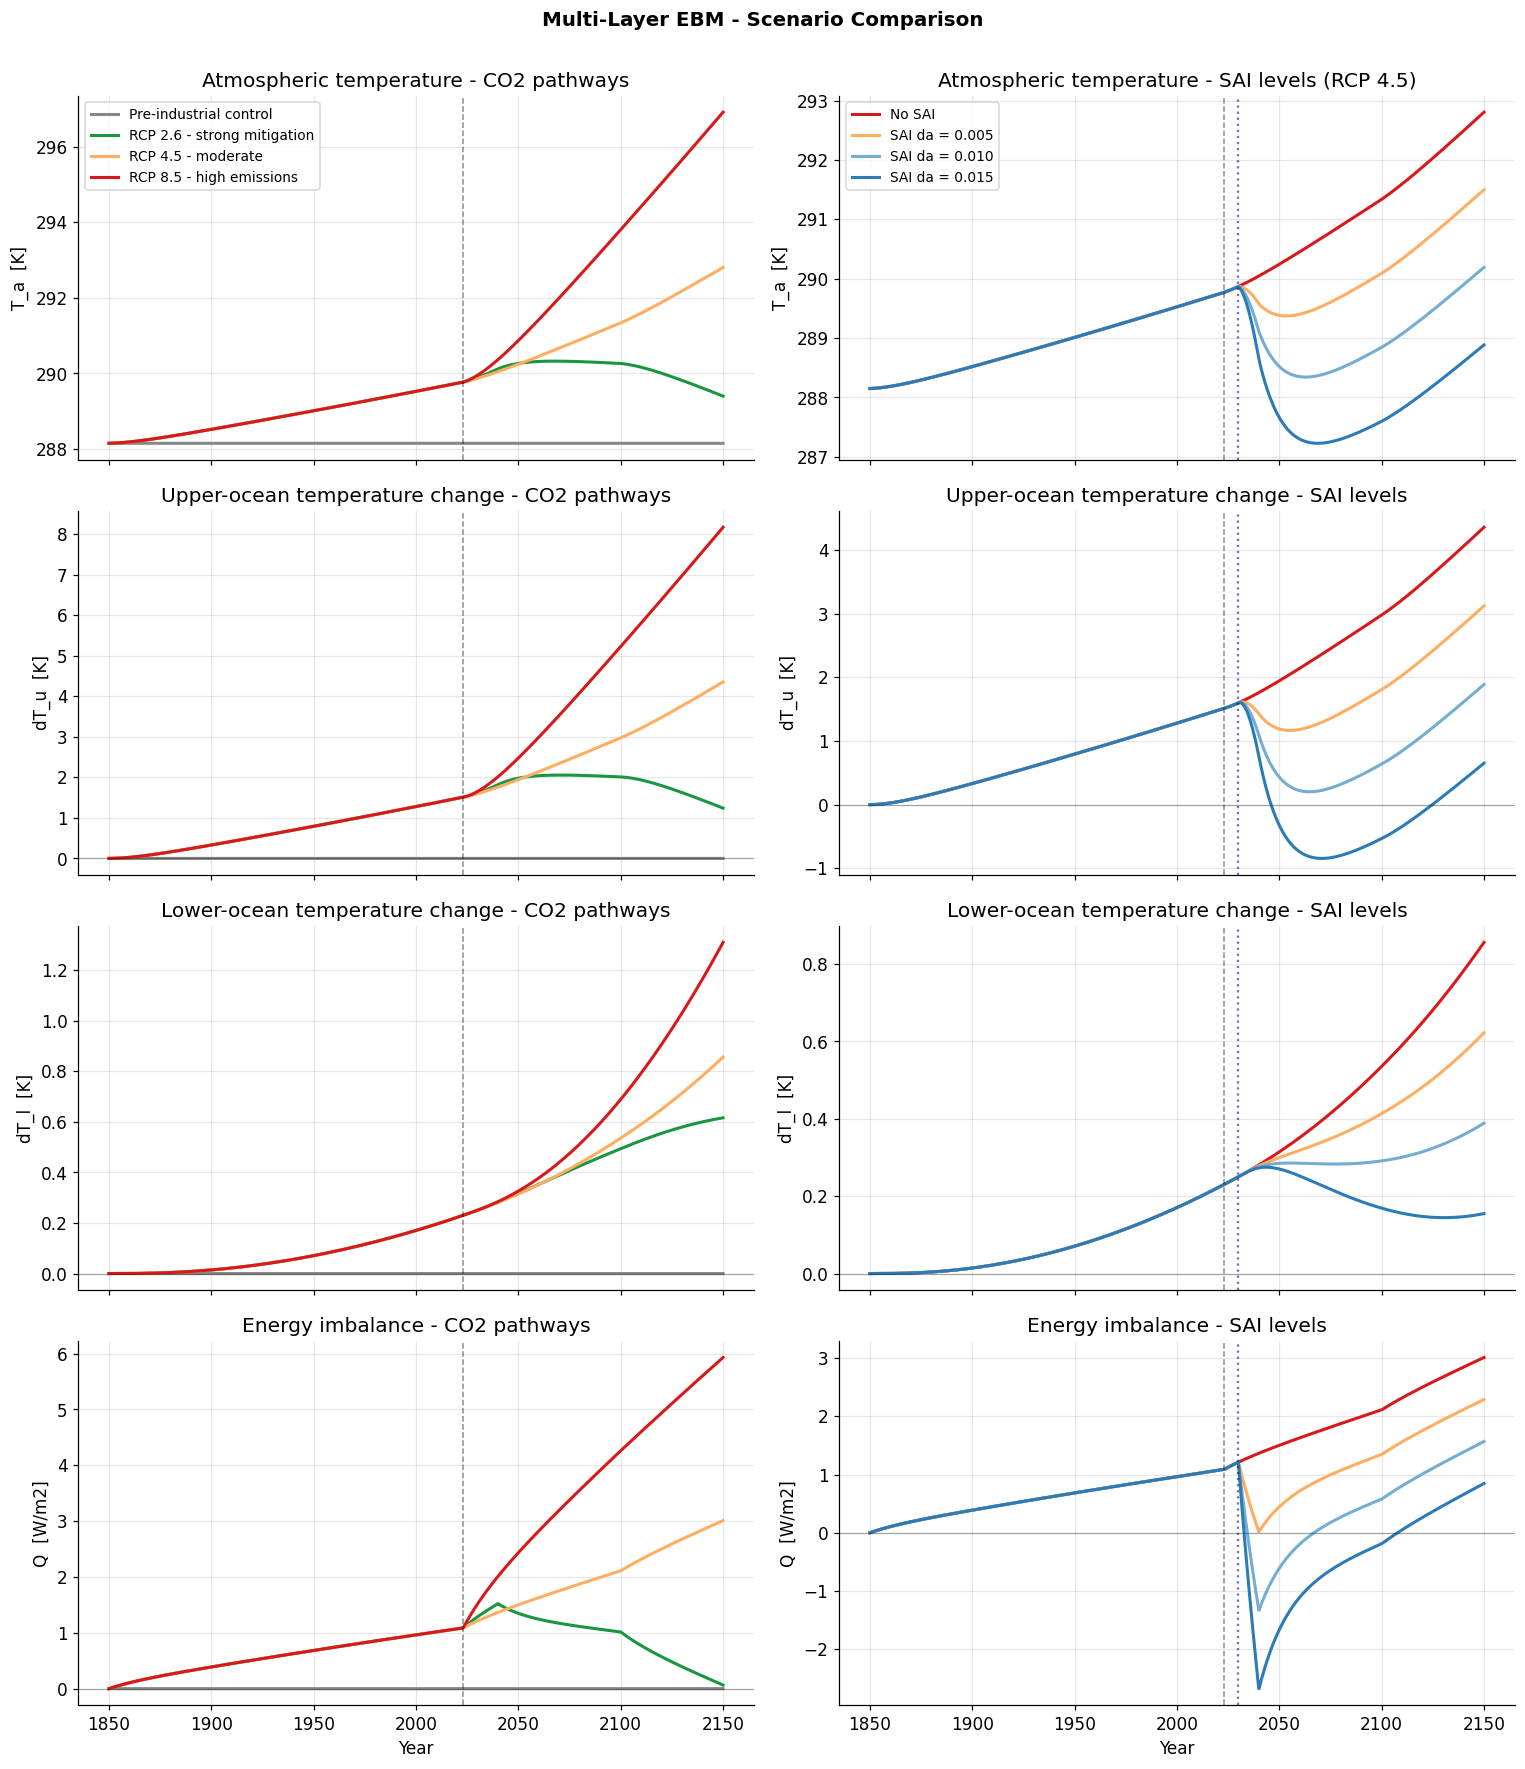

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
fig.suptitle('Multi-Layer EBM - Scenario Comparison', fontsize=13, fontweight='bold', y=1.003)

# -- CO2 scenarios (no SAI), left column --------------------------------------
co2_cases = [
    ('none',  'Pre-industrial control',      '#888888'),
    ('rcp26', 'RCP 2.6 - strong mitigation', '#1a9641'),
    ('rcp45', 'RCP 4.5 - moderate',          '#fdae61'),
    ('rcp85', 'RCP 8.5 - high emissions',    '#d7191c'),
]
for scen, label, color in co2_cases:
    t, Ta, Tu, Tl, Q = run_ebm(scenario=scen, d_alpha=0.0)
    axes[0, 0].plot(t, Ta,      color=color, lw=2, label=label)
    axes[1, 0].plot(t, Tu - T0, color=color, lw=2, label=label)
    axes[2, 0].plot(t, Tl - T0, color=color, lw=2, label=label)
    axes[3, 0].plot(t, Q,       color=color, lw=2, label=label)

# -- SAI levels under RCP 4.5, right column -----------------------------------
sai_cases = [
    (0.000, 'No SAI',          '#d7191c'),
    (0.005, 'SAI da = 0.005',  '#fdae61'),
    (0.010, 'SAI da = 0.010',  '#74add1'),
    (0.015, 'SAI da = 0.015',  '#2c7bb6'),
]
for da, label, color in sai_cases:
    t, Ta, Tu, Tl, Q = run_ebm(scenario='rcp45', d_alpha=da)
    axes[0, 1].plot(t, Ta,      color=color, lw=2, label=label)
    axes[1, 1].plot(t, Tu - T0, color=color, lw=2, label=label)
    axes[2, 1].plot(t, Tl - T0, color=color, lw=2, label=label)
    axes[3, 1].plot(t, Q,       color=color, lw=2, label=label)

# -- Annotations --------------------------------------------------------------
for ax in axes.flat:
    ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.45)
for ax in axes[:, 1]:
    ax.axvline(2030, color='navy', ls=':', lw=1.5, alpha=0.55)
for ax in list(axes[1, :]) + list(axes[2, :]) + list(axes[3, :]):
    ax.axhline(0, color='k', lw=0.8, alpha=0.3)

axes[0, 0].set(title='Atmospheric temperature - CO2 pathways',        ylabel='T_a  [K]')
axes[0, 1].set(title='Atmospheric temperature - SAI levels (RCP 4.5)', ylabel='T_a  [K]')
axes[1, 0].set(title='Upper-ocean temperature change - CO2 pathways',  ylabel='dT_u  [K]')
axes[1, 1].set(title='Upper-ocean temperature change - SAI levels',    ylabel='dT_u  [K]')
axes[2, 0].set(title='Lower-ocean temperature change - CO2 pathways',  ylabel='dT_l  [K]')
axes[2, 1].set(title='Lower-ocean temperature change - SAI levels',    ylabel='dT_l  [K]')
axes[3, 0].set(title='Energy imbalance - CO2 pathways',                ylabel='Q  [W/m2]', xlabel='Year')
axes[3, 1].set(title='Energy imbalance - SAI levels',                  ylabel='Q  [W/m2]', xlabel='Year')

axes[0, 0].legend(fontsize=9)
axes[0, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Interactive Exploration

Adjust the layer heat capacities, the deep-ocean coupling $\gamma_{ul}$, the CO₂ pathway, and
the SAI deployment to see how each shapes the response in real time.

- **Top-left** — atmospheric temperature, with the SAI cooling offset shaded.
- **Top-right** — ocean temperature change for the **upper** (solid) and **lower** (dashed) layers.
- **Bottom-left** — net TOA energy imbalance $Q$ and the **deep-ocean heat uptake** $\gamma_{ul}(T_u-T_l)$.
- **Bottom-right** — energy-balance decomposition $Q = F_{\mathrm{CO_2}} + F_{\mathrm{SAI}} +$ OLR feedback.

In [14]:
def plot_ebm(C_u, C_l, gamma_ul, scenario, d_alpha, sai_start, sai_ramp):
    t_b, Ta_b, Tu_b, Tl_b, Q_b = run_ebm(C_u=C_u, C_l=C_l, gamma_ul=gamma_ul,
                                          scenario=scenario, d_alpha=0.0)
    t_s, Ta_s, Tu_s, Tl_s, Q_s = run_ebm(C_u=C_u, C_l=C_l, gamma_ul=gamma_ul,
                                          scenario=scenario, d_alpha=d_alpha,
                                          sai_start=sai_start, sai_ramp=sai_ramp)

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    fig.suptitle(f'Multi-Layer EBM  |  {scenario.upper()}  |  '
                 f'C_u={C_u:.0f}, C_l={C_l:.0f} W.yr/m2/K, gamma_ul={gamma_ul:.2f}',
                 fontsize=12, fontweight='bold')

    # -- Atmospheric temperature ----------------------------------------------
    ax = axes[0, 0]
    ax.plot(t_b, Ta_b, color='#d7191c', lw=2, label='No SAI')
    ax.plot(t_s, Ta_s, color='#2c7bb6', lw=2, label=f'SAI da = {d_alpha:.3f}')
    ax.fill_between(t_s, Ta_b, Ta_s, where=(Ta_s < Ta_b),
                    alpha=0.15, color='#2c7bb6', label='Cooling offset')
    ax.set(title='Atmospheric temperature', ylabel='T_a  [K]', xlabel='Year')

    # -- Ocean temperature change (upper solid, lower dashed) -----------------
    ax = axes[0, 1]
    ax.plot(t_b, Tu_b - T0, color='#d7191c', lw=2,           label='Upper, no SAI')
    ax.plot(t_s, Tu_s - T0, color='#2c7bb6', lw=2,           label='Upper, SAI')
    ax.plot(t_b, Tl_b - T0, color='#d7191c', lw=2, ls='--',  label='Lower, no SAI')
    ax.plot(t_s, Tl_s - T0, color='#2c7bb6', lw=2, ls='--',  label='Lower, SAI')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Ocean temperature change', ylabel='dT  [K]', xlabel='Year')

    # -- Energy imbalance + deep-ocean heat uptake ----------------------------
    ax = axes[1, 0]
    ax.plot(t_b, Q_b, color='#d7191c', lw=2, label='Q (TOA), no SAI')
    ax.plot(t_s, Q_s, color='#2c7bb6', lw=2, label='Q (TOA), SAI')
    ax.plot(t_b, gamma_ul * (Tu_b - Tl_b), color='#d7191c', lw=1.3, ls=':', label='Deep uptake, no SAI')
    ax.plot(t_s, gamma_ul * (Tu_s - Tl_s), color='#2c7bb6', lw=1.3, ls=':', label='Deep uptake, SAI')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy imbalance & deep-ocean heat uptake', ylabel='W/m2', xlabel='Year')

    # -- Energy-balance decomposition (SAI run) -------------------------------
    ax = axes[1, 1]
    F_co2  = np.array([co2_forcing(ti, scenario=scenario) for ti in t_s])
    F_sai  = np.array([-S * sai_delta_alpha(ti, d_alpha=d_alpha,
                                             start_year=sai_start, ramp_years=sai_ramp) for ti in t_s])
    OLR_fb = -(b * (Ta_s - T0))
    Q_dec  = F_co2 + F_sai + OLR_fb
    ax.fill_between(t_s, F_co2,  alpha=0.35, color='#d7191c', label='CO2 forcing  F(t)')
    ax.fill_between(t_s, F_sai,  alpha=0.35, color='#2c7bb6', label='SAI forcing  -S*da')
    ax.fill_between(t_s, OLR_fb, alpha=0.35, color='#fdae61', label='OLR feedback  -b(Ta-T0)')
    ax.plot(t_s, Q_dec, 'k-', lw=1.6, label='Q  (sum)')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy balance decomposition (SAI run)', ylabel='W/m2', xlabel='Year')

    for ax in axes.flat:
        ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.4)
        if d_alpha > 0:
            ax.axvline(sai_start, color='navy', ls=':', lw=1.5, alpha=0.5)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


interact(
    plot_ebm,
    C_u       = FloatSlider(value=C_UPPER, min=5.0,  max=40.0,  step=1.0,   description='C_u [W.yr/m2/K]', style={'description_width':'initial'}),
    C_l       = FloatSlider(value=C_LOWER, min=50.0, max=600.0, step=10.0,  description='C_l [W.yr/m2/K]', style={'description_width':'initial'}),
    gamma_ul  = FloatSlider(value=GAMMA_UL, min=0.1, max=2.0,   step=0.1,   description='gamma_ul [W/m2/K]', style={'description_width':'initial'}, readout_format='.2f'),
    scenario  = Dropdown(options=['none','rcp26','rcp45','rcp85'], value='rcp45', description='CO2 scenario'),
    d_alpha   = FloatSlider(value=0.0,  min=0.0,  max=0.025, step=0.001, description='SAI da',        style={'description_width':'initial'}, readout_format='.3f'),
    sai_start = IntSlider(  value=2030, min=2025, max=2080,  step=5,     description='SAI start year', style={'description_width':'initial'}),
    sai_ramp  = IntSlider(  value=10,   min=1,    max=30,    step=1,     description='Ramp-up years',  style={'description_width':'initial'}),
);

interactive(children=(FloatSlider(value=18.403032607662325, description='C_u [W.yr/m2/K]', max=40.0, min=5.0, …

## Deep-Ocean Coupling Sensitivity

The new physics in this model is the **deep-ocean heat uptake**, set by $\gamma_{ul}$. A larger
$\gamma_{ul}$ lets heat drain into the lower ocean faster — warming the deep ocean but **slowing**
surface warming and **raising** the persistent energy imbalance $Q$. Below: all four layers'
responses for five values of $\gamma_{ul}$ under RCP 4.5 with a moderate SAI deployment
($\Delta\alpha = 0.010$).

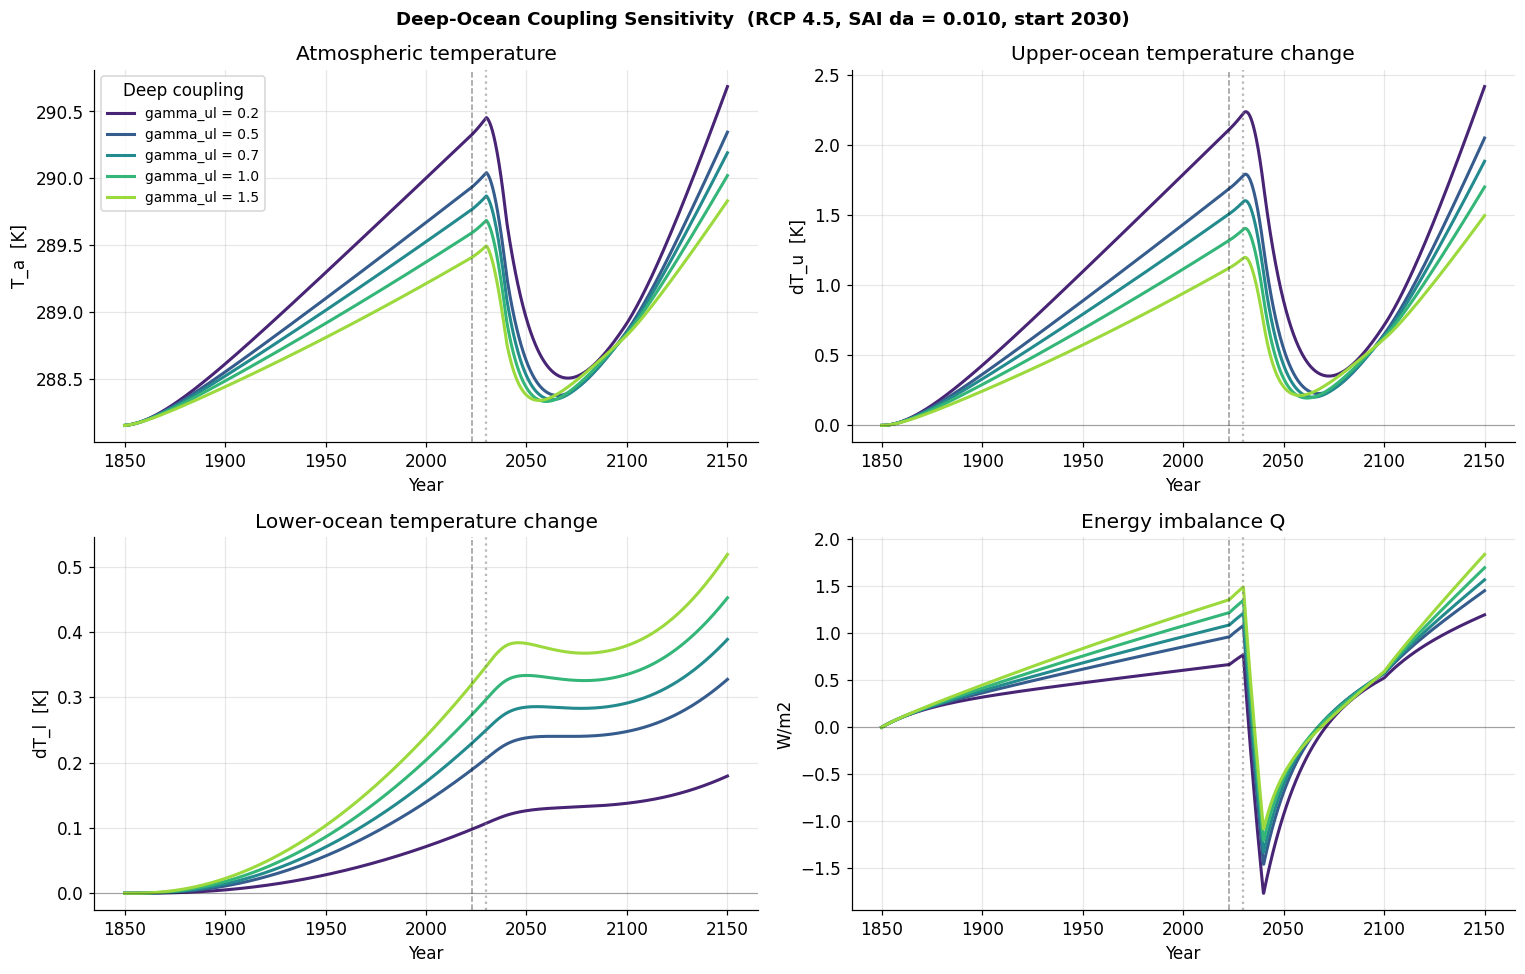

In [15]:
gamma_values = [0.2, 0.5, 0.7, 1.0, 1.5]
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(gamma_values)))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Deep-Ocean Coupling Sensitivity  (RCP 4.5, SAI da = 0.010, start 2030)',
             fontsize=12, fontweight='bold')

for g, color in zip(gamma_values, colors):
    t, Ta, Tu, Tl, Q = run_ebm(scenario='rcp45', d_alpha=0.010, gamma_ul=g)
    axes[0, 0].plot(t, Ta,      color=color, lw=2, label=f'gamma_ul = {g}')
    axes[0, 1].plot(t, Tu - T0, color=color, lw=2)
    axes[1, 0].plot(t, Tl - T0, color=color, lw=2)
    axes[1, 1].plot(t, Q,       color=color, lw=2)

for ax in axes.flat:
    ax.axvline(2023, color='k',    ls='--', lw=1,   alpha=0.4)
    ax.axvline(2030, color='gray', ls=':',  lw=1.5, alpha=0.55)
for ax in (axes[0, 1], axes[1, 0], axes[1, 1]):
    ax.axhline(0, color='k', lw=0.8, alpha=0.3)

axes[0, 0].set(title='Atmospheric temperature',          ylabel='T_a  [K]',  xlabel='Year')
axes[0, 1].set(title='Upper-ocean temperature change',   ylabel='dT_u  [K]', xlabel='Year')
axes[1, 0].set(title='Lower-ocean temperature change',   ylabel='dT_l  [K]', xlabel='Year')
axes[1, 1].set(title='Energy imbalance Q',               ylabel='W/m2',      xlabel='Year')

axes[0, 0].legend(title='Deep coupling', fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
# ── SAI with post-ramp slope ──────────────────────────────────────────────────
# Redefines the sai_delta_alpha → net_toa_imbalance → layer_derivs → run_ebm
# chain to thread a d_alpha_slope parameter (increase in da per year after ramp).

def sai_delta_alpha(t, d_alpha=0.0, start_year=2030, ramp_years=10, d_alpha_slope=0.0):
    """
    Albedo offset from SAI.

    Phase 1 – pre-deployment  [t < start_year]:              0
    Phase 2 – ramp-up         [start_year, start_year+ramp): linear 0 → d_alpha
    Phase 3 – post-ramp       [t >= start_year+ramp):        d_alpha + d_alpha_slope*(t-ramp_end)
    """
    if d_alpha == 0.0 or t < start_year:
        return 0.0
    ramp_end = start_year + ramp_years
    if t < ramp_end:
        return d_alpha * (t - start_year) / ramp_years
    return d_alpha + d_alpha_slope * (t - ramp_end)


def net_toa_imbalance(t, Ta, d_alpha=0.0, scenario='rcp45',
                      sai_start=2030, sai_ramp=10, d_alpha_slope=0.0):
    alpha = alpha0 + sai_delta_alpha(t, d_alpha=d_alpha, start_year=sai_start,
                                     ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope)
    F = co2_forcing(t, scenario=scenario)
    return S * (1 - alpha) - (a + b * Ta) + F


def layer_derivs(t, y, C_a, C_u, C_l, gamma_au, gamma_ul,
                 d_alpha=0.0, scenario='rcp45', sai_start=2030, sai_ramp=10, d_alpha_slope=0.0):
    Ta, Tu, Tl = y
    R    = net_toa_imbalance(t, Ta, d_alpha, scenario, sai_start, sai_ramp, d_alpha_slope)
    f_au = gamma_au * (Ta - Tu)
    f_ul = gamma_ul * (Tu - Tl)
    return [(R - f_au) / C_a,
            (f_au - f_ul) / C_u,
            (f_ul)        / C_l]


def run_ebm(C_a=C_ATMOS, C_u=C_UPPER, C_l=C_LOWER,
            gamma_au=GAMMA_AU, gamma_ul=GAMMA_UL,
            scenario='rcp45', d_alpha=0.0, sai_start=2030, sai_ramp=10,
            d_alpha_slope=0.0, t_span=(1850, 2150), n_pts=2400):
    kw   = dict(d_alpha=d_alpha, scenario=scenario, sai_start=sai_start,
                sai_ramp=sai_ramp, d_alpha_slope=d_alpha_slope)
    args = (C_a, C_u, C_l, gamma_au, gamma_ul)
    t_eval = np.linspace(*t_span, n_pts)
    sol = solve_ivp(lambda t, y: layer_derivs(t, y, *args, **kw),
                    t_span, [T0, T0, T0], t_eval=t_eval,
                    method='BDF', rtol=1e-8, atol=1e-10)
    Ta, Tu, Tl = sol.y
    Q = np.array([net_toa_imbalance(ti, Ta_i, **kw) for ti, Ta_i in zip(sol.t, Ta)])
    return sol.t, Ta, Tu, Tl, Q


def plot_ebm(C_u, C_l, gamma_ul, scenario, d_alpha, sai_start, sai_ramp, d_alpha_slope):
    t_b, Ta_b, Tu_b, Tl_b, Q_b = run_ebm(C_u=C_u, C_l=C_l, gamma_ul=gamma_ul,
                                          scenario=scenario, d_alpha=0.0)
    t_s, Ta_s, Tu_s, Tl_s, Q_s = run_ebm(C_u=C_u, C_l=C_l, gamma_ul=gamma_ul,
                                          scenario=scenario, d_alpha=d_alpha,
                                          sai_start=sai_start, sai_ramp=sai_ramp,
                                          d_alpha_slope=d_alpha_slope)

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    fig.suptitle(f'Multi-Layer EBM  |  {scenario.upper()}  |  '
                 f'C_u={C_u:.0f}, C_l={C_l:.0f} W.yr/m2/K, gamma_ul={gamma_ul:.2f}',
                 fontsize=12, fontweight='bold')

    # -- Atmospheric temperature -----------------------------------------------
    ax = axes[0, 0]
    ax.plot(t_b, Ta_b, color='#d7191c', lw=2, label='No SAI')
    ax.plot(t_s, Ta_s, color='#2c7bb6', lw=2,
            label=f'SAI da={d_alpha:.3f}, slope={d_alpha_slope:.4f}/yr')
    ax.fill_between(t_s, Ta_b, Ta_s, where=(Ta_s < Ta_b),
                    alpha=0.15, color='#2c7bb6', label='Cooling offset')
    ax.set(title='Atmospheric temperature', ylabel='T_a  [K]', xlabel='Year')

    # -- Ocean temperature change ----------------------------------------------
    ax = axes[0, 1]
    ax.plot(t_b, Tu_b - T0, color='#d7191c', lw=2,          label='Upper, no SAI')
    ax.plot(t_s, Tu_s - T0, color='#2c7bb6', lw=2,          label='Upper, SAI')
    ax.plot(t_b, Tl_b - T0, color='#d7191c', lw=2, ls='--', label='Lower, no SAI')
    ax.plot(t_s, Tl_s - T0, color='#2c7bb6', lw=2, ls='--', label='Lower, SAI')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Ocean temperature change', ylabel='dT  [K]', xlabel='Year')

    # -- Energy imbalance + deep-ocean heat uptake -----------------------------
    ax = axes[1, 0]
    ax.plot(t_b, Q_b, color='#d7191c', lw=2, label='Q (TOA), no SAI')
    ax.plot(t_s, Q_s, color='#2c7bb6', lw=2, label='Q (TOA), SAI')
    ax.plot(t_b, gamma_ul * (Tu_b - Tl_b), color='#d7191c', lw=1.3, ls=':', label='Deep uptake, no SAI')
    ax.plot(t_s, gamma_ul * (Tu_s - Tl_s), color='#2c7bb6', lw=1.3, ls=':', label='Deep uptake, SAI')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy imbalance & deep-ocean heat uptake', ylabel='W/m2', xlabel='Year')

    # -- Energy-balance decomposition -----------------------------------------
    ax = axes[1, 1]
    F_co2  = np.array([co2_forcing(ti, scenario=scenario) for ti in t_s])
    F_sai  = np.array([-S * sai_delta_alpha(ti, d_alpha=d_alpha, start_year=sai_start,
                                             ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope)
                        for ti in t_s])
    OLR_fb = -(b * (Ta_s - T0))
    Q_dec  = F_co2 + F_sai + OLR_fb
    ax.fill_between(t_s, F_co2,  alpha=0.35, color='#d7191c', label='CO2 forcing  F(t)')
    ax.fill_between(t_s, F_sai,  alpha=0.35, color='#2c7bb6', label='SAI forcing  -S*da(t)')
    ax.fill_between(t_s, OLR_fb, alpha=0.35, color='#fdae61', label='OLR feedback  -b(Ta-T0)')
    ax.plot(t_s, Q_dec, 'k-', lw=1.6, label='Q  (sum)')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy balance decomposition (SAI run)', ylabel='W/m2', xlabel='Year')

    for ax in axes.flat:
        ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.4)
        if d_alpha > 0:
            ax.axvline(sai_start,             color='navy',      ls=':', lw=1.5, alpha=0.5)
            ax.axvline(sai_start + sai_ramp,  color='steelblue', ls=':', lw=1.0, alpha=0.5)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


interact(
    plot_ebm,
    C_u          = FloatSlider(value=C_UPPER,  min=5.0,  max=40.0,  step=1.0,    description='C_u [W.yr/m2/K]',        style={'description_width': 'initial'}),
    C_l          = FloatSlider(value=C_LOWER,  min=50.0, max=600.0, step=10.0,   description='C_l [W.yr/m2/K]',        style={'description_width': 'initial'}),
    gamma_ul     = FloatSlider(value=GAMMA_UL, min=0.1,  max=2.0,   step=0.1,    description='gamma_ul [W/m2/K]',      style={'description_width': 'initial'}, readout_format='.2f'),
    scenario     = Dropdown(options=['none', 'rcp26', 'rcp45', 'rcp85'], value='rcp45', description='CO2 scenario'),
    d_alpha      = FloatSlider(value=0.0,  min=0.0,  max=0.025, step=0.001,  description='SAI da',                 style={'description_width': 'initial'}, readout_format='.3f'),
    sai_start    = IntSlider(  value=2030, min=2025, max=2080,  step=5,      description='SAI start year',         style={'description_width': 'initial'}),
    sai_ramp     = IntSlider(  value=10,   min=1,    max=30,    step=1,      description='Ramp-up years',          style={'description_width': 'initial'}),
    d_alpha_slope= FloatSlider(value=0.0,  min=0.0,  max=0.0005, step=0.00001, description='Post-ramp slope (da/yr)', style={'description_width': 'initial'}, readout_format='.4f'),
);

interactive(children=(FloatSlider(value=18.403032607662325, description='C_u [W.yr/m2/K]', max=40.0, min=5.0, …